##### ***BERT微调：自然语言推断***
###### 在上一节处理好数据集后，接下来正式进入此任务的微调实践，根据上节的数据集可知，自然语言推断任务其实是一个序列级别的文本对分类问题，而微调BERT只需要一个额外的基于MLP的架构，如下图所示：
###### 当然针对不同的任务要求，所选的微调方式也不同，大致分为MLP,Attention, RNN, CNN等，这里仅讨论本任务的情况。
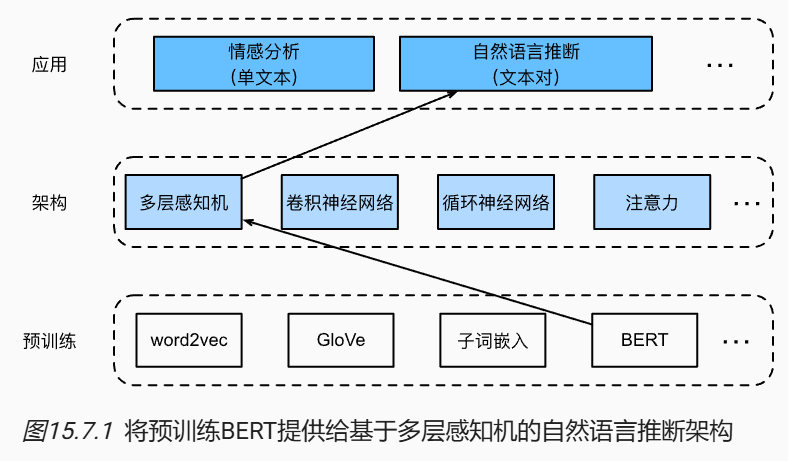

In [1]:
import json
import multiprocessing
import os
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# 加载预训练好的BERT权重
d2l.DATA_HUB['bert.base'] = (d2l.DATA_URL + 'bert.base.torch.zip', '225d66f04cae318b841a13d32af3acc165f253ac')
d2l.DATA_HUB['bert.small'] = (d2l.DATA_URL + 'bert.small.torch.zip', 'c72329e68a732bef0452e4b96a1c341c8910f81f')

In [5]:
def load_pretrained_model(pretrained_model, num_hiddens, ffn_num_hiddens, num_heads, num_layers, dropout, max_len, devices):
    data_dir = d2l.download_extract(pretrained_model)
    vocab = d2l.Vocab()
    vocab.idx_to_token = json.load(open(os.path.join(data_dir, 'vocab.json')))
    vocab.token_to_idx = {token: idx for idx, token in enumerate(vocab.idx_to_token)}
    bert = d2l.BERTModel(len(vocab), num_hiddens, norm_shape=[256], ffn_num_input=256, ffn_num_hiddens=ffn_num_hiddens, num_heads=4, num_layers=2, dropout=0.2, max_len=max_len, key_size=256, query_size=256, value_size=256, hid_in_features=256, mlm_in_features=256, nsp_in_features=256)
    bert.load_state_dict(torch.load(os.path.join(data_dir, 'pretrained.params')))
    return bert, vocab

In [6]:
devices = d2l.try_all_gpus()
bert, vocab = load_pretrained_model(
    'bert.small', num_hiddens=256, ffn_num_hiddens=512, num_heads=4,
    num_layers=2, dropout=0.1, max_len=512, devices=devices)

C:\Users\26650\AppData\Local\Temp\ipykernel_25520\2836493887.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bert.load_state_dict(torch.load(os.path.join(data_dir, 'pret

##### ***微调BERT的数据集***
###### 上一节中我们展示了SNLI数据集，接下来我们要对其进行数据处理，使其符合微调任务。具体来说，在每个样本中，前提和假设是一对文本序列，并被打包成一个BERT输入序列，片段索引用于区分前提和假设。利用预定义的BERT的输入序列的最大长度max_len，持续移除输入文本对中较长文本的最后一个标记，直到满足max_len。

In [7]:
class SNLIBERTDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, max_len, vocab=None):
        all_premise_hypothesis_tokens = [[
            p_tokens, h_tokens] for p_tokens, h_tokens in zip(
            *[d2l.tokenize([s.lower() for s in sentences])
              for sentences in dataset[:2]])]

        self.labels = torch.tensor(dataset[2])
        self.vocab = vocab
        self.max_len = max_len
        (self.all_token_ids, self.all_segments,
         self.valid_lens) = self._preprocess(all_premise_hypothesis_tokens)
        print('read ' + str(len(self.all_token_ids)) + ' examples')

    def _preprocess(self, all_premise_hypothesis_tokens):
        pool = multiprocessing.Pool(4)  # 使用4个进程
        out = pool.map(self._mp_worker, all_premise_hypothesis_tokens)
        all_token_ids = [
            token_ids for token_ids, segments, valid_len in out]
        all_segments = [segments for token_ids, segments, valid_len in out]
        valid_lens = [valid_len for token_ids, segments, valid_len in out]
        return (torch.tensor(all_token_ids, dtype=torch.long),
                torch.tensor(all_segments, dtype=torch.long),
                torch.tensor(valid_lens))

    def _mp_worker(self, premise_hypothesis_tokens):
        p_tokens, h_tokens = premise_hypothesis_tokens
        self._truncate_pair_of_tokens(p_tokens, h_tokens)
        tokens, segments = d2l.get_tokens_and_segments(p_tokens, h_tokens)
        token_ids = self.vocab[tokens] + [self.vocab['<pad>']] \
                             * (self.max_len - len(tokens))
        segments = segments + [0] * (self.max_len - len(segments))
        valid_len = len(tokens)
        return token_ids, segments, valid_len

    def _truncate_pair_of_tokens(self, p_tokens, h_tokens):
        # 为BERT输入中的'<CLS>'、'<SEP>'和'<SEP>'词元保留位置
        while len(p_tokens) + len(h_tokens) > self.max_len - 3:
            if len(p_tokens) > len(h_tokens):
                p_tokens.pop()
            else:
                h_tokens.pop()

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx]), self.labels[idx]

    def __len__(self):
        return len(self.all_token_ids)

In [ ]:
# 实例化SNLIDataset类来生成训练和测试样本
# 如果出现显存不足错误，请减少“batch_size”。在原始的BERT模型中，max_len=512
batch_size, max_len, num_workers = 512, 128, d2l.get_dataloader_workers()
data_dir = None
candidate_dirs = [
        os.path.join('data', 'snli_1.0'),
        os.path.join('..', 'data', 'snli_1.0')
    ]
for candidate in candidate_dirs:
    if os.path.exists(os.path.join(candidate, 'snli_1.0_train.txt')):
        data_dir = candidate
        break
if data_dir is None:
    data_dir = d2l.download_extract('SNLI')
train_set = SNLIBERTDataset(d2l.read_snli(data_dir, True), max_len, vocab)
test_set = SNLIBERTDataset(d2l.read_snli(data_dir, False), max_len, vocab)
train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True,
                                   num_workers=num_workers)
test_iter = torch.utils.data.DataLoader(test_set, batch_size,
                                  num_workers=num_workers)

In [ ]:
# 微调BERT，对于下游任务通过不同的输出层，即可完成对应任务的区分
class BERTClassifier(nn.Module):
    def __init__(self, bert):
        super(BERTClassifier, self).__init__()
        self.encoder = bert.encoder
        self.hidden = bert.hidden
        self.output = nn.Linear(256, 3)
    
    def forward(self, inputs):
        tokens_X, segments_X, valid_lens_x = inputs
        encoded_X = self.encoder(tokens_X, segments_X, valid_lens_x)
        return self.output(self.hidden(encoded_X[:, 0, :]))

In [ ]:
net = BERTClassifier(bert)

In [ ]:
lr, num_epochs = 1e-4, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

##### ***BERT与Transformer、GPT、Seq2Seq的关系***
###### 从结构来源上看，BERT继承自Transformer，但只保留了编码器部分，因此它不是完整的Transformer翻译模型。Transformer最初是为Seq2Seq任务提出的，属于编码器-解码器架构；BERT则将其中的编码器单独拿出来，发展成专门做理解的预训练模型。
###### 与BERT不同，GPT使用的是Transformer的解码器路线，并采用自回归方式进行训练，也就是根据前文预测下一个词。因此二者最大的差异在于：
###### 1. BERT是**双向建模**，更适合理解；
###### 2. GPT是**单向自回归建模**，更适合生成；
###### 3. Seq2Seq模型更适合翻译、摘要这类输入输出都明确的任务。
###### 所以可以简单记成：**BERT偏理解，GPT偏生成，经典Transformer最早偏Seq2Seq。**

##### ***BERT的优点与局限性***
###### BERT的优点在于：一方面它利用双向上下文表示，大幅提升了语言理解能力；另一方面它把预训练和微调结合起来，使得NLP任务不再需要从零开始设计复杂模型，而是可以基于统一的预训练模型进行迁移。
###### 但BERT也有很明显的局限性。首先，它的MLM训练方式与推理阶段并不完全一致，因为预训练中使用了`[MASK]`，而实际应用时通常并不会出现这个特殊词元；其次，BERT不是自回归模型，不擅长长文本连续生成；最后，随着模型规模和应用场景扩大，encoder-only结构在通用生成式任务上逐渐被GPT类decoder-only模型超越。

##### ***从BERT到现代LLM的视角***
###### 从今天的角度回看，BERT最大的意义并不只是它在具体榜单上取得了多高的成绩，而是它证明了：**大规模预训练 + 下游微调**这条路线是可行的。后续的GPT、T5、BART以及更大规模的LLM，都继承了“先进行大规模预训练，再针对目标行为进行后续适配”的核心思想。只不过BERT更偏理解，现代主流LLM则更多走向了生成式路线。
###### 因此在学习路径上，可以把BERT看作是从词向量时代走向大模型时代的重要桥梁：它承接了上下文表示学习的需求，又借助Transformer打开了预训练语言模型的新阶段。

##### ***总结***
###### BERT是一个基于Transformer编码器的双向预训练语言模型，它通过MLM和NSP等任务学习上下文敏感的表示，特别适合理解类NLP任务。它既不同于最初用于翻译的Seq2Seq Transformer，也不同于后来的GPT式生成模型，但它在“预训练+微调”范式上的成功，为现代LLM的发展奠定了非常重要的基础。